## Basics

In [1]:
def get_results_for_p(p,all_results):
    # Create the key as a tuple
    #key = (p.num_z,p.num_v,p.num_n,p.n_bar,p.num_q,p.q_0,p.prod_q,p.hire_c,p.k_entry,p.k_f,p.prod_alpha,p.dt)
    key = (p.num_z,p.num_v,p.z_corr,p.prod_var_z,p.num_q,p.q_0,p.prod_q,p.s_job,p.alpha,p.kappa,p.dt,p.u_bf_m,p.min_wage,p.delta)
    # Check if the key exists in the saved results
    if key in all_results:
        print(key)
        return all_results[key]
    else:
        print(f"No results found for p = {key}")
        return None
new_baseline = {
   'q_0': 0.56602, 'prod_q':	0.50425,'u_bf_m':	2.34264/4,'s_job':	0.779616,'alpha':	0.72,'z_corr':	0.946006,'prod_var_z':	0.646317, 'min_wage': 2.34264/4,
}
shitty_baseline ={
   'q_0':  0.507071,'prod_q':	0.789495,'u_bf_m':	0.602856,'s_job':	0.83867,'alpha':	0.469883,'z_corr':	0.887682,'prod_var_z':	0.671289, 'min_wage': 0.602856	
}
shitty_baseline_edited ={
   'q_0':  0.607071,'prod_q':	0.789495,'u_bf_m':	0.40,'s_job':	0.83867,'alpha':	0.77,'z_corr':	0.887682,'prod_var_z':	0.671289, 'min_wage': 0.45	
}
new_baseline_lower_b = {
   'q_0': 0.56602, 'prod_q':	0.50425,'u_bf_m':	0.5,'s_job':	0.779616,'alpha':	0.72,'z_corr':	0.946006,'prod_var_z':	0.646317, 'min_wage': 2.34264/4,
}

from primitives import Parameters
p = Parameters(overwrite=new_baseline_lower_b)
import pickle
import matplotlib.pyplot as plt
import numpy as np
from plots import Plots
plts=Plots(p)

# Baseline

In [2]:
new_baseline_lower_b = {
   'q_0': 0.70602, 'prod_q':	0.60425,'u_bf_m':	0.5,'s_job':	0.779616,'alpha':	0.9,'z_corr':	0.946006,'prod_var_z':	0.40, 'min_wage': 2.34264/4,
}
new_baseline_lower_b = {
#   'q_0': 0.70602, 'prod_q':	0.60425,'u_bf_m':	0.4,'s_job':	0.779616,'alpha':	0.9,'z_corr':	0.946006,'prod_var_z':	0.40, 'min_wage': 2.34264/4,
#   'q_0': 0.56602, 'prod_q':	0.50425,'u_bf_m':	0.4,'s_job':	0.779616,'alpha':	0.72,'z_corr':	0.946006,'prod_var_z':	0.646317, 'min_wage': 0.4, #Hre min wage was too low
#   'q_0': 0.56602, 'prod_q':	0.50425,'u_bf_m':	0.3,'s_job':	0.779616,'alpha':	0.72,'z_corr':	0.946006,'prod_var_z':	0.646317, 'min_wage': 0.5, #Here min wage almost perfect, but wage growth, pr new hire still lagging
#   'q_0': 0.45, 'prod_q':	0.45,'u_bf_m':	1.0,'s_job':	0.779616,'alpha':	0.72,'z_corr':	0.946006,'prod_var_z':	0.646317, 'min_wage': 1.8, 'prod_a': 4.0,  #Best version with prod == 4? Noop the best one is below
#   'q_0': 0.67, 'prod_q':	0.67,'u_bf_m':	0.38,'s_job':	0.78,'alpha':	0.68,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3, # best "calibrated" version with prod_a=1.3. produces shitty regressions tho, also layoff rate not very high
#   'q_0': 0.57, 'prod_q':	0.67,'u_bf_m':	0.7,'s_job':	0.78,'alpha':	0.68,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3, # trying higher unemp_bf + the search thing (set unemp worker search as if no assets)
#   'q_0': 0.57, 'prod_q':	0.67,'u_bf_m':	0.7,'s_job':	0.78,'alpha':	0.94,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3, # trying higher alpha
#   'q_0': 0.57, 'prod_q':	0.67,'u_bf_m':	0.7,'s_job':	0.98,'alpha':	0.99,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3, # raised job-finding values even further, j2j rate is good now
#   'q_0': 0.57, 'prod_q':	0.60,'u_bf_m':	0.8,'s_job':	0.98,'alpha':	0.95,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.8, 'prod_a': 1.3, 'kappa': 0.2, #now raising layoffs slightly+raising wage growth (too low again). also working with kappa instead of alpha. soo far very weird
# Getting nice moments with this one, so going for it again:
# 'q_0': 0.66, 'prod_q':	0.67,'u_bf_m':	0.6,'s_job':	0.78,'alpha':	0.88,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3,
# 'q_0': 0.66, 'prod_q':	0.67,'u_bf_m':	0.6,'s_job':	0.78,'alpha':	0.88,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 1.01, 'prod_a': 1.3, 'delta': 0.005,#Higher min wage, trying to have the baseline
#'q_0': 0.66, 'prod_q':	0.67,'u_bf_m':	0.65,'s_job':	0.78,'alpha':	0.88,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.5, 'prod_a': 1.0, 'delta': 0.005,#Lowering the baseline productivity back down since the job-finding rate is too high
'q_0': 0.56, 'prod_q':	0.47,'u_bf_m':	0.65,'s_job':	0.78,'kappa':	0.8,'z_corr':	0.91,'prod_var_z':	0.78, 'min_wage': 0.5, 'prod_a': 1.0, 'delta': 0.01,#Trying the calibratioon for yearly simulation

   'sim_nt': 44, 'sim_nt_burn': 50, 'sim_nh': 1000, 'sim_ni' : 20000 #44 quarters for 11 years: 2009-2019
}
from primitives import Parameters
p = Parameters(overwrite=new_baseline_lower_b)

from CRS_HMQ_all_savings import MultiworkerContract

with open("model_GE_all_saving.pkl", "rb") as file:
    all_results = pickle.load(file)
model = get_results_for_p(p,all_results)
#model=None
if model is None:
   mwc_J=MultiworkerContract(p,print_choice_simple=False)
   model=mwc_J.J_sep(update_eq=1,s=0,print_choice=True)

(7, 100, 0.91, 0.78, 10, 0.56, 0.47, 0.78, 1.0, 0.8, 0.25, 0.65, 0.5, 0.01)


In [3]:
#'q_0': 0.56, 'prod_q':	0.47,'u_bf_m':	0.65,'s_job':	0.78,'kappa':	0.8,'z_corr':	0.91,'prod_var_z':	0.78, 'min_wage': 0.5, 'prod_a': 1.0, 'delta': 0.01,#Trying the calibratioon for yearly simulation
np.random.seed(42)
from simulate_saving_yearly import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(20)
moms_mean

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:571: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\frame.py:11218: RuntimeWarning: Degrees of freedom <= 0 for slice
  base_cov = np.cov(mat.T, ddof=ddof)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\zaloilo\AppData\Local\Progra

total_output               1.035371
total_wage                 0.860589
total_uben                 0.000597
mean_wage                  0.935901
u_rate                     0.080470
min_mean_ratio             0.534252
workers_on_min_w           0.000000
pr_u2e                     0.207324
pr_j2j                     0.000000
pr_j2j_an                  0.000000
pr_e2u                     0.017852
cov_dydw                        NaN
pr_new_hire                0.000010
pr_new_hire_y              0.017936
pr_new_hire_sdata_ten      0.000000
pr_new_hire_old            0.017936
avg_w_growth_10            0.301880
avg_w_growth_10_y          0.244129
avg_ten_prof_10           -0.086887
sd_dypw                    0.229521
autocov_ypw                0.166869
autocov_ypw_alt            0.652460
layoffs_share_tercile_0    0.017538
layoffs_share_tercile_1    0.017477
layoffs_share_tercile_2    0.017252
Name: value_model, dtype: float64

In [10]:
def cf_model_to_life(p,junior, update_prod=False, pr_cache=False):
    """
    We simulate the response of several variables to a shock to z and x.
    We fixed the cross-section distribution of (X,Z) and set rho to rho_start
    We apply a permanent shock to either X or Z, and fix the employment relationship, as well as (X,Z)
    We then simulate forward the Rho, and the wage, and report several different variable of interest.
    """
    import pandas as pd

    nt = 20#20*4
    # we load the model
    with open("model_GE_all_saving.pkl", "rb") as file:
        all_results = pickle.load(file)
    model = get_results_for_p(p,all_results)
    if model is None:
        from CRS_HMQ_full import MultiworkerContract
        mwc_J=MultiworkerContract(p)
        model=mwc_J.J_sep(update_eq=1,s=0)
    #model = wd.FullModel.load("res_main_model.pkl")


    # we simulate from the model to get a cross-section
    from simulate_saving_yearly import Simulator
    sim = Simulator(model, p)
    sdata = sim.simulate().get_sdata()
    print("Solved and simulated")
    # we construct the different starting values
    tm = sdata['t'].max()
    if junior:
        d0 = sdata.query('e==1 & t==@tm & s<=1')[['q','z','h','r']] #Only check the new matches
    else:
        d0 = sdata.query('e==1 & t==@tm')[['q','z','h','r']]
    # we start at target rho
    z_idx=d0['z'].to_numpy()
    q_vals = d0['q'].to_numpy()

    # 1) Using a list comprehension (simple, robust)
    R0 = np.array([
    np.interp(q, model.Q_grid, model.target_rho[iz, :])
    for iz, q in zip(z_idx, q_vals)
    ])
    print("target_rho range 1d interp", R0.min(), R0.max())
    print("q range", d0['q'].min(),d0['q'].max())
    #Now, what if we DON'T do the target rho thing?
    R0 = d0['r']
    # starting with Z shocks
    def get_z_pos(pr):
        Z1_pos = np.minimum(sdata['z'].max(), d0['z'] + 1)
        Z1_pos = np.where(np.random.uniform(size=len(Z1_pos)) > pr, Z1_pos, d0['z']  )
        return(Z1_pos)

    def get_z_neg(pr):
        Z1_neg = np.maximum(0, d0['z'] - 1)
        Z1_neg = np.where(np.random.uniform(size=len(Z1_neg)) > pr, Z1_neg, d0['z']  )
        return(Z1_neg)

    # simulate a control group
    var_name = {'q':r'proportion of high quality matches $q$', 
                'w':r'log earnings $\log w$', 
                'W1':'worker promised value $v\'$', 
                'lceq':'worker cons. eq.', 
                'Pi':r'match present value $\partial J(y,\{n_k,v_k,z_k\})/\partial n_k$', 
                'y':r'log firm productivity shock', 
                'pr_j2j':'J2J probability', 
                'pr_e2u':'E2U probability',
                'target_wage':'log target wage $\log w^*(y,\{n_v,v_l,z_k\})$',
                'vs':'worker search decision $\hat{v}$'}
    var_list = { k:'mean' for k in var_name.keys()  }

    def sim_agg(dd):
        # compute consumption equivalent for W1
        dd['lceq'] = model.pref.log_consumption_eq(dd['W1'])
        dd['lpeq'] = model.pref.log_profit_eq(dd['W1'])
        return(dd.groupby('t').agg(var_list))

    sdata0 = sim_agg(sim.simulate_force_ee(d0['q'],d0['z'],d0['h'],R0, nt,  update_z=False, pb=True))
    print("Control group simulated")
    # we run for a grid of probabilities
    if pr_cache:
        with open("res_cf_pr_fb{}.json".format(first_best)) as f:
            all = json.load(f)
    else:
        all = []
        vec = np.linspace(0,1,10)
        for i in range(len(vec)):
            res = {}
            res['pr'] = vec[i]
            pr = vec[i]
            res['z_pos'] = sim.simulate_force_ee(
                    d0['q'], get_z_pos(pr), d0['h'],R0, nt, 
                     update_z=False, pb=True)['y'].mean() 
            res['z_neg'] = sim.simulate_force_ee(
                    d0['q'], get_z_neg(pr), d0['h'],R0, nt, 
                     update_z=False, pb=True)['y'].mean() 
            all.append(res)

        # save to file!
        # with open("res_cf_pr_fb{}.json".format(first_best), 'w') as fp:
        #     json.dump(all, fp)
    
    df = pd.DataFrame(all)

    df = df.sort_values(['z_pos'])
    pr_z_pos = np.interp( sdata0['y'].mean() + 0.1, df['z_pos'] , df['pr'] )
    df = df.sort_values(['z_neg'])
    pr_z_neg = np.interp( sdata0['y'].mean() - 0.1, df['z_neg'] , df['pr'] )
    

 
    sdata0 = sim_agg(sim.simulate_force_ee(d0['q'],d0['z'],d0['h'],R0, nt, update_z=update_prod, pb=True))
    print("Ran for a grid of probabilities?")
    # finaly we simulate at the probabilities that we have chosen.
    sdata_z_pos = sim_agg(sim.simulate_force_ee(
        d0['q'],get_z_pos(pr_z_pos),d0['h'],R0, nt, 
        update_z=update_prod,pb=True))

    sdata_z_neg = sim_agg(sim.simulate_force_ee(
        d0['q'],get_z_neg(pr_z_neg),d0['h'],R0, nt, 
        update_z=update_prod,pb=True))

    # preparing the lead and lag plots
    pp0 = lambda v : np.concatenate([ np.zeros(5), v ])
    ppt = lambda v : np.concatenate([ [-4,-3,-2,-1,0], v ])
    
    to_plot = {'w','pr_j2j','pr_e2u','vs','q','Pi','y','W1','target_wage'}
    to_plot = {k:v for k,v in var_name.items() if k in to_plot}
    print("Plotting")
    # Z shock response
    plt.clf()
    # plt.rcParams["figure.figsize"]=12,12
    plt.figure(figsize=(12, 12), dpi=80)
    for i,name in enumerate(to_plot.keys()):
        plt.subplot(3, 3, i+1)
        plt.plot( ppt (sdata0.index) , pp0(sdata_z_pos[name] - sdata0[name]) )
        plt.plot( ppt (sdata0.index) , pp0(sdata_z_neg[name] - sdata0[name]), linestyle='--')
        plt.axhline(0,linestyle=':',color="black")
        plt.xlabel(var_name[name])
        #plt.xlabel('years')
        plt.xticks(range(0,21,5))
        plt.ticklabel_format(axis="y", style="sci", scilimits=(-3,5))
    plt.subplots_adjust(hspace=0.3, wspace=0.3)

    if junior:
        plt.savefig('figure-ir-zshock-junior.pdf', bbox_inches='tight')
    else:
        plt.savefig('figure-ir-zshock.pdf', bbox_inches='tight')

(7, 100, 0.91, 0.78, 10, 0.56, 0.47, 0.78, 1.0, 0.8, 0.25, 0.65, 0.5, 0.01)
Solved and simulated
target_rho range 1d interp 1.131562155969775 1.131562155969775
q range 0.56 0.56


100%|██████████| 20/20 [00:00<00:00, 192.02it/s]
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Control group simulated


100%|██████████| 20/20 [00:00<00:00, 191.54it/s]
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Ran for a grid of probabilities?


100%|██████████| 20/20 [00:00<00:00, 166.77it/s]
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
100%|██████████| 20/20 [00:00<00:00, 207.07it/s]
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Plotting


<Figure size 640x480 with 0 Axes>

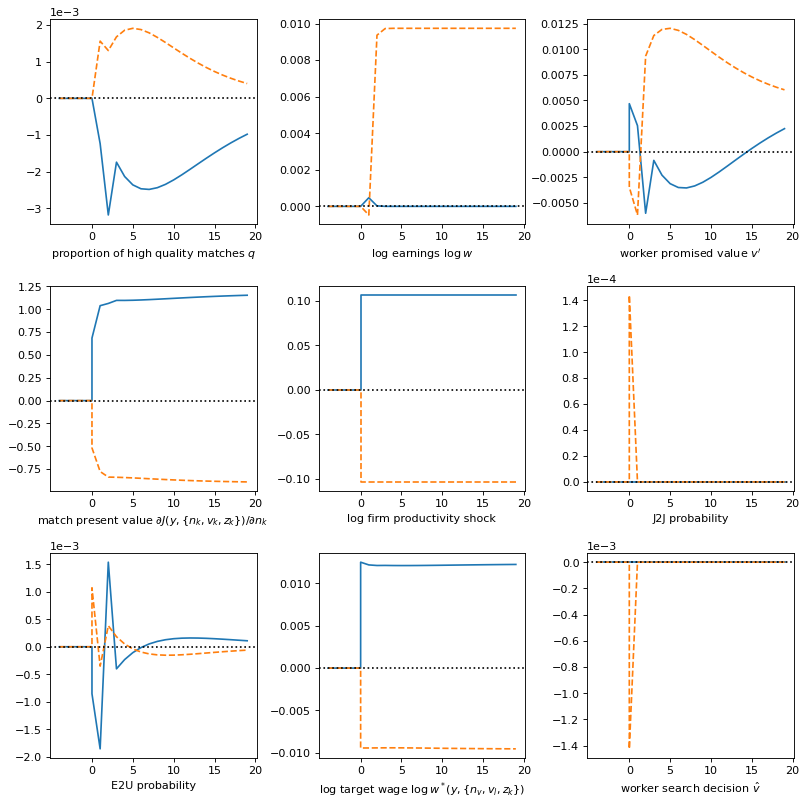

In [12]:
cf_model_to_life(p,junior=True, update_prod=False, pr_cache=False)

(7, 100, 0.91, 0.78, 10, 0.56, 0.47, 0.78, 1.0, 0.8, 0.25, 0.65, 0.5, 0.01)
Solved and simulated
target_rho range 1d interp 1.0763090777384277 1.3237800217625955
q range 0.56 0.9999999999994226


100%|██████████| 20/20 [00:00<00:00, 24.40it/s]
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Control group simulated


100%|██████████| 20/20 [00:00<00:00, 27.12it/s]
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Ran for a grid of probabilities?


100%|██████████| 20/20 [00:00<00:00, 35.17it/s]
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
100%|██████████| 20/20 [00:00<00:00, 39.08it/s]
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Plotting


<Figure size 640x480 with 0 Axes>

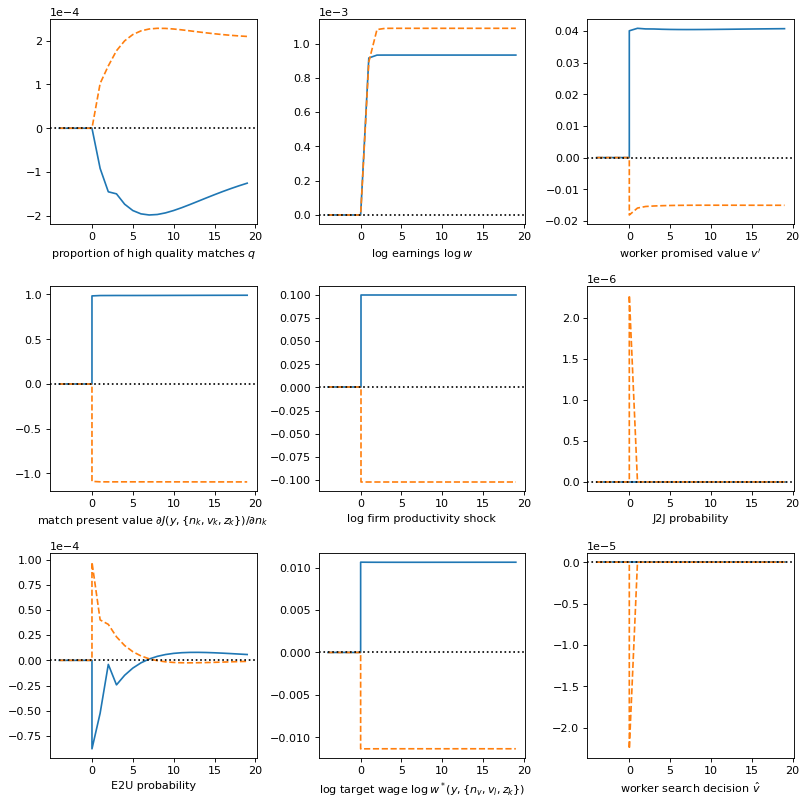

In [11]:
#Simulating basically evolved matches already
cf_model_to_life(p,junior=False, update_prod=False, pr_cache=False)

#Another interesting point of comparison: juniors in particular!
#cf_model_to_life(p,junior=True, update_prod=False, pr_cache=False)

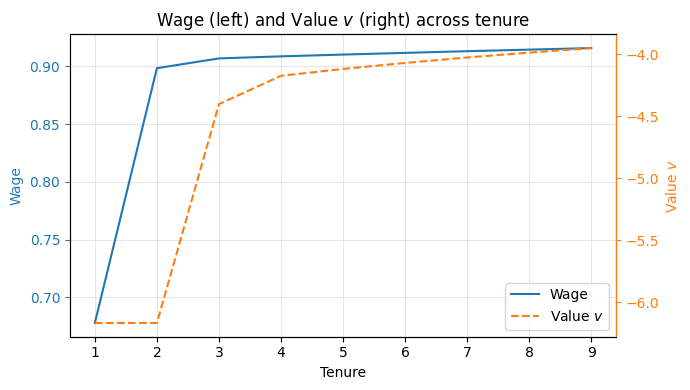

In [4]:
sim.plot_w_v_twin(save_path="True_w_v_twin_by_tenure.jpg")

In [5]:
moms_unt_mean['wage_pass_ten_y']
#moms_unt_mean['sep_ten']

coef
Intercept               2.815539e-01
dypw                   -3.130053e-17
C(tenure)[T.3]         -2.722191e-01
C(tenure)[T.4]         -2.796151e-01
C(tenure)[T.5]         -2.798878e-01
C(tenure)[T.6]         -2.799766e-01
C(tenure)[T.7]         -2.800034e-01
C(tenure)[T.8]         -2.801149e-01
C(tenure)[T.9]         -2.801092e-01
C(tenure)[T.10]        -2.801805e-01
C(tenure)[T.3]:dypw    -5.953968e-05
C(tenure)[T.4]:dypw    -1.344400e-05
C(tenure)[T.5]:dypw     4.759904e-05
C(tenure)[T.6]:dypw    -7.498707e-05
C(tenure)[T.7]:dypw    -3.627503e-05
C(tenure)[T.8]:dypw     1.302135e-05
C(tenure)[T.9]:dypw    -1.611928e-04
C(tenure)[T.10]:dypw   -1.114766e-04
Name: regressions_mean, dtype: float64

In [ ]:
#'q_0': 0.66, 'prod_q':	0.67,'u_bf_m':	0.65,'s_job':	0.78,'alpha':	0.88,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.5, 'prod_a': 1.0, 'delta': 0.005,#Lowering the baseline productivity back down since the job-finding rate is too high

np.random.seed(42)
from simulate_saving_yearly import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(20)
moms_mean

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:571: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\frame.py:11218: RuntimeWarning: Degrees of freedom <= 0 for slice
  base_cov = np.cov(mat.T, ddof=ddof)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\zaloilo\AppData\Local\Progra

total_output               1.140887
total_wage                 1.050683
total_uben                 0.000645
mean_wage                  1.093871
u_rate                     0.039486
min_mean_ratio             0.457094
workers_on_min_w           0.000000
pr_u2e                     0.293704
pr_j2j                     0.008248
pr_j2j_an                  0.032557
pr_e2u                     0.011763
cov_dydw                        NaN
pr_new_hire                0.000008
pr_new_hire_y              0.020012
pr_new_hire_sdata_ten      0.000000
pr_new_hire_old            0.020012
avg_w_growth_10            0.048744
avg_w_growth_10_y          0.090523
sd_dypw                    0.207065
autocov_ypw                0.118689
autocov_ypw_alt            0.617844
layoffs_share_tercile_0    0.014868
layoffs_share_tercile_1    0.013140
layoffs_share_tercile_2    0.011836
Name: value_model, dtype: float64

In [ ]:
moms_unt_mean['wage_pass_ten_y']
moms_unt_mean['sep_ten']

In [5]:
#Implied average job-finding duration:
1/0.21 #okay, so it only take 2.7 quarters to find a job right now, less than half of what it takes in souchier's model...
#so the job-finding rate is way too high  rn

4.761904761904762

In [2]:
1/1.175

0.851063829787234

In [7]:
4.7*3

14.100000000000001

In [4]:
1/(13.8/3) #that's the pru2e that we want

0.21739130434782605

In [9]:
#Let's try to get some other statistics across tenure
emp = sim.sdata.loc[sim.sdata['h'] >= 0].copy()
emp['w_exp'] = np.exp(emp['w'])
g = (emp
         .groupby('tenure')
         .agg(w=('w_exp', 'mean'),
              v=('v', 'mean'),
              q=('q', 'mean'),
              r = ('r', 'mean'),
              f = ('f', 'mean'),
              z = ('z', 'mean')))

In [ ]:
import numpy as np
np.exp(sim.sdata.query('h>=0')['w']).max()- np.exp(sim.sdata.query('h>=0')['w']).min()

In [ ]:
g['w'] #the wage is never even below 1! min wage has no impact at all here (NOT GOOD ACTUALLY!!! WHY DO WAGES START SO FUCKING HIGH??? OR, MORE GENERALLY, WHY ARE WAGES SO COMPRESSED?)

In [ ]:
g_z = (emp
         .groupby(['tenure','z'])
         .agg(w=('w_exp', 'mean'),
              v=('v', 'mean'),
              q=('q', 'mean'),
              r = ('r', 'mean'),
              f = ('f', 'mean')))

In [3]:
model.Vf_U[0] - model.Vf_W.min() #Should be negative. it is eh? nice

np.float64(-1.0198981304599464)

In [10]:
#model.Pr_u2e
model.rho_u2e

np.float64(0.9574254128260942)

## Plotting the layoffs and wage passthrough

## Baseline

In [3]:
#'q_0': 0.66, 'prod_q':	0.67,'u_bf_m':	0.65,'s_job':	0.78,'alpha':	0.88,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.5, 'prod_a': 1.0, 'delta': 0.005,#Lowering the baseline productivity back down since the job-finding rate is too high
np.random.seed(42)
from simulate_saving import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(20)
moms_mean

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = ge

total_output               1.140887e+00
total_wage                 1.050683e+00
total_uben                 6.445581e-04
mean_wage                  1.093871e+00
u_rate                     3.948605e-02
min_mean_ratio             4.570942e-01
workers_on_min_w           0.000000e+00
pr_u2e                     2.937037e-01
pr_j2j                     8.248056e-03
pr_j2j_an                  3.255697e-02
pr_e2u                     1.176329e-02
cov_dydsep                -9.181905e-02
var_dy                     9.204576e-02
cov_dydy_l4                2.713152e-03
cov_dydw                   2.270701e-03
var_w_longac              -2.951558e-07
var_w                      1.002356e-03
cov_dwdw_l4                3.952558e-05
cov_dwdw_l8               -7.944584e-05
var_dw                     4.837985e-04
mean_dw                   -3.093535e-05
w_u2e_ee_gap               7.916041e-02
mean_dw_j2j_2              1.614066e-02
pr_new_hire                3.382658e-05
pr_new_hire_y              1.429134e-02


In [3]:
#'q_0': 0.66, 'prod_q':	0.67,'u_bf_m':	0.6,'s_job':	0.78,'alpha':	0.88,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.5, 'prod_a': 1.0, 'delta': 0.005,#Lowering the baseline productivity back down since the job-finding rate is too high
np.random.seed(42)
from simulate_saving import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(20)
moms_mean

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = ge

total_output               9.245759e-01
total_wage                 5.734717e-01
total_uben                 5.537791e-04
mean_wage                  6.207673e-01
u_rate                     7.618895e-02
min_mean_ratio             8.054548e-01
workers_on_min_w           5.484127e-03
pr_u2e                     6.696521e-02
pr_j2j                     4.403137e-06
pr_j2j_an                  1.761241e-05
pr_e2u                     4.985026e-03
cov_dydsep                -1.149239e-04
var_dy                     1.044053e-01
cov_dydy_l4                2.931649e-03
cov_dydw                   1.061493e-06
var_w_longac              -5.729298e-06
var_w                      1.719812e-05
cov_dwdw_l4                9.656204e-11
cov_dwdw_l8                2.373104e-16
var_dw                     1.732250e-05
mean_dw                    3.410842e-04
w_u2e_ee_gap               5.528447e-02
mean_dw_j2j_2             -4.752734e-03
pr_new_hire                0.000000e+00
pr_new_hire_y              5.552968e-03


In [4]:
#'q_0': 0.66, 'prod_q':	0.67,'u_bf_m':	0.6,'s_job':	0.78,'alpha':	0.88,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 1.01, 'prod_a': 1.3, 'delta': 0.005
np.random.seed(42)
from simulate_saving import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(10)
moms_mean

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = ge

total_output               1.484254
total_wage                 1.312644
total_uben                 0.000573
mean_wage                  1.358323
min_mean_ratio             0.743625
workers_on_min_w           0.012646
pr_u2e                     0.374509
pr_j2j                     0.010181
pr_j2j_an                  0.040093
pr_e2u                     0.012661
cov_dydsep                -0.106732
var_dy                     0.087581
cov_dydy_l4               -0.000553
cov_dydw                   0.002741
var_w_longac              -0.000036
var_w                      0.004046
cov_dwdw_l4                0.000124
cov_dwdw_l8               -0.000076
var_dw                     0.000866
mean_dw                    0.003810
w_u2e_ee_gap               0.151115
mean_dw_j2j_2             -0.014496
pr_new_hire                0.000050
pr_new_hire_y              0.016471
pr_new_hire_sdata_ten      0.055219
pr_new_hire_old            0.022826
avg_w_growth_10            0.142625
avg_w_growth_10_y          0

In [ ]:
moms_unt_mean['wage_pass_ten_y']


coef
Intercept              0.117176
dypw                  -0.026503
C(tenure)[T.2]        -0.010854
C(tenure)[T.3]        -0.093393
C(tenure)[T.4]        -0.116294
C(tenure)[T.5]        -0.117521
C(tenure)[T.6]        -0.117692
C(tenure)[T.7]        -0.117687
C(tenure)[T.8]        -0.117701
C(tenure)[T.9]        -0.117721
C(tenure)[T.2]:dypw    0.025358
C(tenure)[T.3]:dypw    0.022818
C(tenure)[T.4]:dypw    0.023227
C(tenure)[T.5]:dypw    0.022798
C(tenure)[T.6]:dypw    0.022421
C(tenure)[T.7]:dypw    0.022218
C(tenure)[T.8]:dypw    0.022084
C(tenure)[T.9]:dypw    0.022129
Name: regressions_mean, dtype: float64

In [5]:
moms_unt_mean['sep_ten']

coef
Intercept         0.294257
C(tenure)[T.2]   -0.252642
C(tenure)[T.3]   -0.278496
C(tenure)[T.4]   -0.284402
C(tenure)[T.5]   -0.285932
C(tenure)[T.6]   -0.286573
C(tenure)[T.7]   -0.286400
C(tenure)[T.8]   -0.286877
C(tenure)[T.9]   -0.287346
Name: regressions_mean, dtype: float64

In [ ]:
#'q_0': 0.66, 'prod_q':	0.67,'u_bf_m':	0.6,'s_job':	0.78,'alpha':	0.88,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.95, 'prod_a': 1.3
np.random.seed(42)
from simulate_saving import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(10)
moms_mean

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = ge

total_output               1.531921
total_wage                 1.369449
total_uben                 0.000827
mean_wage                  1.387952
min_mean_ratio             0.727729
workers_on_min_w           0.004714
pr_u2e                     0.387370
pr_j2j                     0.008928
pr_j2j_an                  0.035201
pr_e2u                     0.004679
cov_dydsep                -0.143265
var_dy                     0.089194
cov_dydy_l4                0.001978
cov_dydw                   0.002321
var_w_longac               0.000039
var_w                      0.002221
cov_dwdw_l4                0.000074
cov_dwdw_l8               -0.000070
var_dw                     0.000584
mean_dw                    0.001188
w_u2e_ee_gap               0.156572
mean_dw_j2j_2              0.002771
pr_new_hire                0.000020
pr_new_hire_y              0.009817
pr_new_hire_sdata_ten      0.033132
pr_new_hire_old            0.013639
avg_w_growth_10            0.088225
avg_w_growth_10_y          0

In [7]:
moms_unt_mean['wage_pass_ten_y'] #why is this guy so much worse at HIGHER tenures???

coef
Intercept                0.033681
dypw                     0.032982
C(tenure)[T.1.0]        -0.020774
C(tenure)[T.2.0]        -0.027310
C(tenure)[T.3.0]        -0.028294
C(tenure)[T.4.0]        -0.029018
C(tenure)[T.5.0]        -0.029781
C(tenure)[T.6.0]        -0.030210
C(tenure)[T.7.0]        -0.030798
C(tenure)[T.8.0]        -0.031869
C(tenure)[T.9.0]        -0.032244
C(tenure)[T.1.0]:dypw   -0.000104
C(tenure)[T.2.0]:dypw    0.002269
C(tenure)[T.3.0]:dypw    0.003410
C(tenure)[T.4.0]:dypw    0.003224
C(tenure)[T.5.0]:dypw    0.002759
C(tenure)[T.6.0]:dypw    0.000228
C(tenure)[T.7.0]:dypw    0.000611
C(tenure)[T.8.0]:dypw   -0.003212
C(tenure)[T.9.0]:dypw   -0.004249
Name: regressions_mean, dtype: float64

In [6]:
moms_unt_mean['sep_ten']

coef
Intercept           0.042609
C(tenure)[T.1.0]   -0.034709
C(tenure)[T.2.0]   -0.037264
C(tenure)[T.3.0]   -0.038615
C(tenure)[T.4.0]   -0.039628
C(tenure)[T.5.0]   -0.039784
C(tenure)[T.6.0]   -0.040759
C(tenure)[T.7.0]   -0.041015
C(tenure)[T.8.0]   -0.040946
C(tenure)[T.9.0]   -0.041267
Name: regressions_mean, dtype: float64

## No min wage case

In [ ]:
#'q_0': 0.66, 'prod_q':	0.67,'u_bf_m':	0.6,'s_job':	0.78,'alpha':	0.88,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3
#I keep this as a non-min wage case
#Another nice one for moments (but not passthrough) is
#   'q_0': 0.57, 'prod_q':	0.67,'u_bf_m':	0.7,'s_job':	0.98,'alpha':	0.99,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3, # raised job-finding values even further

np.random.seed(42)
from simulate_saving import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(10)
moms_mean

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = ge

total_output               1.552670
total_wage                 1.396571
total_uben                 0.000685
mean_wage                  1.416011
min_mean_ratio             0.459060
workers_on_min_w           0.000000
pr_u2e                     0.396261
pr_j2j                     0.009690
pr_j2j_an                  0.038126
pr_e2u                     0.005037
cov_dydsep                -0.133592
var_dy                     0.082730
cov_dydy_l4                0.000420
cov_dydw                   0.002975
var_w_longac              -0.000030
var_w                      0.002525
cov_dwdw_l4                0.000104
cov_dwdw_l8               -0.000075
var_dw                     0.000740
mean_dw                    0.001202
w_u2e_ee_gap               0.176383
mean_dw_j2j_2              0.005708
pr_new_hire                0.000028
pr_new_hire_y              0.010804
pr_new_hire_sdata_ten      0.036478
pr_new_hire_old            0.014783
avg_w_growth_10            0.119847
avg_w_growth_10_y          0

In [8]:
moms_unt_mean['wage_pass_ten_y']

coef
Intercept                0.031560
dypw                     0.031872
C(tenure)[T.1.0]        -0.010321
C(tenure)[T.2.0]        -0.023636
C(tenure)[T.3.0]        -0.025378
C(tenure)[T.4.0]        -0.026819
C(tenure)[T.5.0]        -0.027908
C(tenure)[T.6.0]        -0.028731
C(tenure)[T.7.0]        -0.030007
C(tenure)[T.8.0]        -0.030735
C(tenure)[T.9.0]        -0.031091
C(tenure)[T.1.0]:dypw    0.009997
C(tenure)[T.2.0]:dypw    0.016367
C(tenure)[T.3.0]:dypw    0.018933
C(tenure)[T.4.0]:dypw    0.018232
C(tenure)[T.5.0]:dypw    0.016118
C(tenure)[T.6.0]:dypw    0.016866
C(tenure)[T.7.0]:dypw    0.012386
C(tenure)[T.8.0]:dypw    0.012357
C(tenure)[T.9.0]:dypw    0.010881
Name: regressions_mean, dtype: float64

In [9]:
moms_unt_mean['sep_ten']

coef
Intercept           0.058771
C(tenure)[T.1.0]   -0.051680
C(tenure)[T.2.0]   -0.053761
C(tenure)[T.3.0]   -0.054442
C(tenure)[T.4.0]   -0.055771
C(tenure)[T.5.0]   -0.056189
C(tenure)[T.6.0]   -0.056198
C(tenure)[T.7.0]   -0.056767
C(tenure)[T.8.0]   -0.057253
C(tenure)[T.9.0]   -0.057389
Name: regressions_mean, dtype: float64

In [ ]:
#   'q_0': 0.57, 'prod_q':	0.50,'u_bf_m':	0.8,'s_job':	0.98,'alpha':	0.95,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.8, 'prod_a': 1.3, 'kappa': 0.4, #lowered prod_q and q_0 again cuz why not eh
from simulate_saving import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(10)
moms_mean

In [ ]:
#   'q_0': 0.67, 'prod_q':	0.67,'u_bf_m':	0.8,'s_job':	0.98,'alpha':	0.95,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.8, 'prod_a': 1.3, 'kappa': 0.4, #higher unemp value togenerate actual layoffs. didnt work lmao. alsoo no j2j transitions
from simulate_saving import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(10)
moms_mean

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\frame.py:11218: RuntimeWarning: Degrees of freedom <= 0 for slice
  base_cov = np.cov(mat.T, ddof=ddof)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_div

total_output               1.446105
total_wage                 1.239380
total_uben                 0.000790
mean_wage                  1.241953
min_mean_ratio             0.644152
workers_on_min_w           0.000333
pr_u2e                     0.298352
pr_j2j                     0.000000
pr_j2j_an                  0.000000
pr_e2u                     0.000301
cov_dydsep                -0.068138
var_dy                     0.100073
cov_dydy_l4                0.006779
cov_dydw                   0.000513
var_w_longac               0.000204
var_w                      0.000670
cov_dwdw_l4                0.000012
cov_dwdw_l8               -0.000002
var_dw                     0.000059
mean_dw                    0.001352
w_u2e_ee_gap               0.141558
mean_dw_j2j_2              0.004859
pr_new_hire                0.000000
pr_new_hire_y              0.000243
pr_new_hire_sdata_ten      0.000830
pr_new_hire_old            0.000333
avg_w_growth_10            0.356295
avg_w_growth_10_y          0

In [3]:
#   'q_0': 0.67, 'prod_q':	0.67,'u_bf_m':	0.7,'s_job':	0.98,'alpha':	0.95,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.75, 'prod_a': 1.3, 'kappa': 0.4, #now raising layoffs slightly+raising wage growth (too low again). also working with kappa instead of alpha. soo far very weird
from simulate_saving import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(10)
moms_mean

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\frame.py:11218: RuntimeWarning: Degrees of freedom <= 0 for slice
  base_cov = np.cov(mat.T, ddof=ddof)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_div

total_output               1.512896e+00
total_wage                 1.065006e+00
total_uben                 7.031744e-04
mean_wage                  1.066180e+00
min_mean_ratio             7.034461e-01
workers_on_min_w           4.772735e-05
pr_u2e                     2.602196e-01
pr_j2j                     0.000000e+00
pr_j2j_an                  0.000000e+00
pr_e2u                     2.128153e-05
cov_dydsep                -5.319075e-02
var_dy                     1.168846e-01
cov_dydy_l4                5.113629e-03
cov_dydw                   9.485086e-07
var_w_longac                        NaN
var_w                      1.182089e-06
cov_dwdw_l4                2.368961e-08
cov_dwdw_l8                1.270942e-09
var_dw                     9.171089e-07
mean_dw                    1.066957e-05
w_u2e_ee_gap               1.656223e-01
mean_dw_j2j_2             -1.112816e-04
pr_new_hire                0.000000e+00
pr_new_hire_y              2.350387e-05
pr_new_hire_sdata_ten      6.965857e-05


In [3]:
#   'q_0': 0.57, 'prod_q':	0.67,'u_bf_m':	0.7,'s_job':	0.98,'alpha':	0.99,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3, # raised job-finding values even further
from simulate_saving import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(10)
moms_mean

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = ge

total_output               1.443589
total_wage                 1.354951
total_uben                 0.000557
mean_wage                  1.367948
min_mean_ratio             0.475168
pr_u2e                     0.426652
pr_j2j                     0.015470
pr_j2j_an                  0.060404
pr_e2u                     0.003810
cov_dydsep                -0.210243
var_dy                     0.080687
cov_dydy_l4               -0.004479
cov_dydw                   0.002185
var_w_longac               0.000220
var_w                      0.000706
cov_dwdw_l4               -0.000021
cov_dwdw_l8               -0.000100
var_dw                     0.000533
mean_dw                   -0.001433
w_u2e_ee_gap               0.103343
mean_dw_j2j_2              0.019657
pr_new_hire                0.000022
pr_new_hire_y              0.017197
pr_new_hire_sdata_ten      0.051429
pr_new_hire_old            0.019189
avg_w_growth_10            0.117210
avg_w_growth_10_y          0.002250
avg_ten_prof_10            0

In [ ]:
#   'q_0': 0.57, 'prod_q':	0.67,'u_bf_m':	0.7,'s_job':	0.78,'alpha':	0.94,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3, # trying higher alpha. moments look fine but the passthrough is off somehow. let's keep searching then
from simulate_saving import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(10)
moms_mean

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = ge

total_output               1.514593
total_wage                 1.362760
total_uben                 0.000730
mean_wage                  1.387086
min_mean_ratio             0.468634
pr_u2e                     0.381706
pr_j2j                     0.008543
pr_j2j_an                  0.033680
pr_e2u                     0.006429
cov_dydsep                -0.111271
var_dy                     0.092718
cov_dydy_l4                0.000477
cov_dydw                   0.002595
var_w_longac              -0.000011
var_w                      0.002754
cov_dwdw_l4                0.000103
cov_dwdw_l8               -0.000070
var_dw                     0.000634
mean_dw                    0.001413
w_u2e_ee_gap               0.138956
mean_dw_j2j_2              0.016214
pr_new_hire                0.000036
pr_new_hire_y              0.009142
pr_new_hire_sdata_ten      0.033270
pr_new_hire_old            0.014960
avg_w_growth_10            0.064295
avg_w_growth_10_y          0.110283
avg_ten_prof_10            0

In [3]:
#   'q_0': 0.57, 'prod_q':	0.67,'u_bf_m':	0.7,'s_job':	0.78,'alpha':	0.68,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3, # trying higher unemp_bf + the search thing (set unemp worker search as if no assets)
from simulate_saving import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(10)
moms_mean

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = ge

total_output               1.459955e+00
total_wage                 1.407633e+00
total_uben                 6.949535e-04
mean_wage                  1.411173e+00
min_mean_ratio             4.606171e-01
pr_u2e                     2.838455e-01
pr_j2j                     2.440038e-04
pr_j2j_an                  9.753929e-04
pr_e2u                     3.543896e-04
cov_dydsep                -6.054521e-02
var_dy                     1.137661e-01
cov_dydy_l4                5.093376e-03
cov_dydw                   5.439579e-04
var_w_longac              -1.048780e-05
var_w                      1.509587e-03
cov_dwdw_l4                5.643052e-05
cov_dwdw_l8                1.256261e-06
var_dw                     2.322847e-04
mean_dw                    2.286493e-03
w_u2e_ee_gap               2.710823e-01
mean_dw_j2j_2              1.275124e-02
pr_new_hire                9.103385e-07
pr_new_hire_y              4.576703e-04
pr_new_hire_sdata_ten      1.662455e-03
pr_new_hire_old            7.026825e-04


In [ ]:
#   'q_0': 0.67, 'prod_q':	0.67,'u_bf_m':	0.38,'s_job':	0.78,'alpha':	0.68,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3, # best "calibrated" version with prod_a=1.3. produces shitty regressions tho, also layoff rate not very high
from simulate_saving import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(10)
moms_mean

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = ge

total_output               1.446333
total_wage                 1.361237
total_uben                 0.000438
mean_wage                  1.375914
min_mean_ratio             0.472425
pr_u2e                     0.300034
pr_j2j                     0.007969
pr_j2j_an                  0.031461
pr_e2u                     0.002875
cov_dydsep                -0.229970
var_dy                     0.089304
cov_dydy_l4               -0.001001
cov_dydw                   0.002454
var_w_longac               0.000511
var_w                      0.001424
cov_dwdw_l4                0.000061
cov_dwdw_l8               -0.000128
var_dw                     0.000774
mean_dw                   -0.000606
w_u2e_ee_gap               0.278120
mean_dw_j2j_2              0.014314
pr_new_hire                0.000004
pr_new_hire_y              0.010649
pr_new_hire_sdata_ten      0.031412
pr_new_hire_old            0.010862
avg_w_growth_10            0.264603
avg_w_growth_10_y          0.041730
avg_ten_prof_10            0

In [ ]:
#   'q_0': 0.45, 'prod_q':	0.45,'u_bf_m':	1.2,'s_job':	0.779616,'alpha':	0.72,'z_corr':	0.946006,'prod_var_z':	0.646317, 'min_wage': 1.8,  'prod_a': 4.0, #This is with prod_a=4!! Generally not tooo bad here, just new hires and j2j that sucks
from simulate_saving import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(10)
moms_mean

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = ge

total_output               4.562482
total_wage                 3.796971
total_uben                 0.001333
mean_wage                  3.849339
min_mean_ratio             0.467706
pr_u2e                     0.402602
pr_j2j                     0.004146
pr_j2j_an                  0.016474
pr_e2u                     0.005085
cov_dydsep                -0.050821
var_dy                     0.054356
cov_dydy_l4                0.004565
cov_dydw                   0.001909
var_w_longac               0.000102
var_w                      0.008025
cov_dwdw_l4                0.000227
cov_dwdw_l8               -0.000026
var_dw                     0.000963
mean_dw                    0.004820
w_u2e_ee_gap               0.231316
mean_dw_j2j_2              0.023353
pr_new_hire                0.000029
pr_new_hire_y              0.004545
pr_new_hire_sdata_ten      0.018858
pr_new_hire_old            0.009268
avg_w_growth_10            0.114059
avg_w_growth_10_y          0.199568
sd_dypw                    0

In [ ]:
#   'q_0': 0.56602, 'prod_q':	0.50425,'u_bf_m':	0.2,'s_job':	0.779616,'alpha':	0.72,'z_corr':	0.946006,'prod_var_z':	0.646317, 'min_wage': 0.5,

from simulate_saving import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(10)
moms_mean

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = ge

total_output               4.484387
total_wage                 3.828997
total_uben                 0.001622
mean_wage                  3.999035
min_mean_ratio             0.550142
pr_u2e                     0.303435
pr_j2j                     0.010608
pr_j2j_an                  0.041730
pr_e2u                     0.013106
cov_dydsep                -0.059358
var_dy                     0.043695
cov_dydy_l4                0.004246
cov_dydw                   0.001015
var_w_longac              -0.000011
var_w                      0.004021
cov_dwdw_l4                0.000093
cov_dwdw_l8               -0.000020
var_dw                     0.000549
mean_dw                   -0.000371
w_u2e_ee_gap               0.079372
mean_dw_j2j_2              0.091060
pr_new_hire                0.000077
pr_new_hire_y              0.011781
pr_new_hire_sdata_ten      0.047531
pr_new_hire_old            0.023749
avg_w_growth_10           -0.019125
avg_w_growth_10_y          0.145236
sd_dypw                    0

In [ ]:
#   'q_0': 0.56602, 'prod_q':	0.50425,'u_bf_m':	0.3,'s_job':	0.779616,'alpha':	0.72,'z_corr':	0.946006,'prod_var_z':	0.646317, 'min_wage': 0.5, #Here min wage almost perfect, but wage growth, pr new hire still lagging

from simulate_saving import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(10)
moms_mean

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = ge

total_output               1.126906
total_wage                 1.031038
total_uben                 0.000292
mean_wage                  1.043277
min_mean_ratio             0.479260
pr_u2e                     0.325227
pr_j2j                     0.004590
pr_j2j_an                  0.018228
pr_e2u                     0.003533
cov_dydsep                -0.059865
var_dy                     0.047610
cov_dydy_l4                0.004353
cov_dydw                   0.000607
var_w_longac              -0.000107
var_w                      0.000815
cov_dwdw_l4                0.000012
cov_dwdw_l8               -0.000014
var_dw                     0.000139
mean_dw                   -0.000670
w_u2e_ee_gap               0.075032
mean_dw_j2j_2              0.050674
pr_new_hire                0.000022
pr_new_hire_y              0.004864
pr_new_hire_sdata_ten      0.018097
pr_new_hire_old            0.008131
avg_w_growth_10            0.068218
avg_w_growth_10_y          0.110004
sd_dypw                    0

In [ ]:
#   'q_0': 0.56602, 'prod_q':	0.50425,'u_bf_m':	0.4,'s_job':	0.779616,'alpha':	0.72,'z_corr':	0.946006,'prod_var_z':	0.646317, 'min_wage': 0.4, #Hre min wage was too low
from simulate_saving import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(10)
moms_mean

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = ge

total_output               1.139134
total_wage                 1.021784
total_uben                 0.000311
mean_wage                  1.040393
min_mean_ratio             0.384481
pr_u2e                     0.307484
pr_j2j                     0.006975
pr_j2j_an                  0.027578
pr_e2u                     0.005364
cov_dydsep                -0.069494
var_dy                     0.053112
cov_dydy_l4                0.004413
cov_dydw                   0.000898
var_w_longac              -0.000007
var_w                      0.002255
cov_dwdw_l4                0.000030
cov_dwdw_l8               -0.000021
var_dw                     0.000253
mean_dw                   -0.001514
w_u2e_ee_gap               0.062298
mean_dw_j2j_2              0.074769
pr_new_hire                0.000053
pr_new_hire_y              0.007533
pr_new_hire_sdata_ten      0.027436
pr_new_hire_old            0.012332
avg_w_growth_10            0.025356
avg_w_growth_10_y          0.111929
sd_dypw                    0

In [ ]:
new_baseline_nominw = {
   'q_0': 0.56602, 'prod_q':	0.50425,'u_bf_m':	0.5,'s_job':	0.779616,'alpha':	0.72,'z_corr':	0.946006,'prod_var_z':	0.646317, 'min_wage': 0.5,
}
from primitives import Parameters
p = Parameters(overwrite=new_baseline_nominw)

from CRS_HMQ_all_savings import MultiworkerContract

with open("model_GE_all_saving.pkl", "rb") as file:
    all_results = pickle.load(file)
model = get_results_for_p(p,all_results)
model = None
if model is None:
   mwc_J=MultiworkerContract(p,print_choice_simple=False)
   model=mwc_J.J_sep(update_eq=1,s=0,print_choice=False)

(7, 200, 0.946006, 0.646317, 6, 0.56602, 0.50425, 0.779616, 0.72, 1.0, 0.25, 0.5, 0.5)


In [ ]:
new_baseline_minw_hike = {
   'q_0': 0.56602, 'prod_q':	0.50425,'u_bf_m':	0.5,'s_job':	0.779616,'alpha':	0.72,'z_corr':	0.946006,'prod_var_z':	0.646317, 'min_wage': 1.2 * (2.34264/4),
}
from primitives import Parameters
p = Parameters(overwrite=new_baseline_minw_hike)

from CRS_HMQ_all_savings import MultiworkerContract

with open("model_GE_all_saving.pkl", "rb") as file:
    all_results = pickle.load(file)
model = get_results_for_p(p,all_results)
model = None
if model is None:
   mwc_J=MultiworkerContract(p,print_choice_simple=False)
   model=mwc_J.J_sep(update_eq=1,s=0,print_choice=False)

(7, 200, 0.946006, 0.646317, 6, 0.56602, 0.50425, 0.779616, 0.72, 1.0, 0.25, 0.5, 0.702792)


In [7]:
shitty_baseline ={
   'q_0':  0.507071,'prod_q':	0.789495,'u_bf_m':	0.602856,'s_job':	0.83867,'alpha':	0.469883,'z_corr':	0.887682,'prod_var_z':	0.671289, 'min_wage': 0.602856	
}
from primitives import Parameters
p = Parameters(overwrite=shitty_baseline)

from CRS_HMQ_all_savings import MultiworkerContract

with open("model_GE_all_saving.pkl", "rb") as file:
    all_results = pickle.load(file)
model = get_results_for_p(p,all_results)
model = None
if model is None:
   mwc_J=MultiworkerContract(p,print_choice_simple=False)
   model=mwc_J.J_sep(update_eq=1,s=0,print_choice=False)

No results found for p = (7, 200, 0.887682, 0.671289, 6, 0.507071, 0.789495, 0.83867, 0.469883, 1.0, 0.25, 0.602856, 0.602856)
Results for p = (7, 200, 0.887682, 0.671289, 6, 0.507071, 0.789495, 0.83867, 0.469883, 1.0, 0.25, 0.602856, 0.602856) have been appended to results_GE_all_saving.pkl.
Results for p = (7, 200, 0.887682, 0.671289, 6, 0.507071, 0.789495, 0.83867, 0.469883, 1.0, 0.25, 0.602856, 0.602856) have been appended to model_GE_all_saving.pkl.


####   Beautiful w_v growth graph (copy 3) using
'q_0': 0.57, 'prod_q':	0.67,'u_bf_m':	0.7,'s_job':	0.78,'alpha':	0.68,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3, # trying higher unemp_bf + the search thing (set unemp worker search as if no assets)


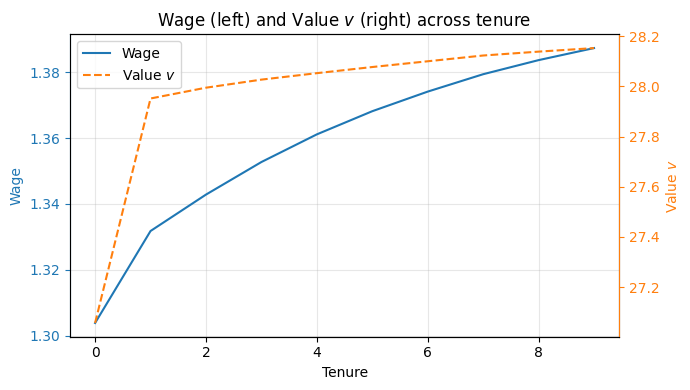

In [4]:
sim.plot_w_v_twin(save_path="True_w_v_twin_by_tenure.jpg")
#why THE FUCK IS THIS GOING DOWN???

## NOTE: I achieved the positive w and v growth (ones in the draft) with shitty_baseline ={
   'q_0':  0.507071,'prod_q':	0.789495,'u_bf_m':	0.602856,'s_job':	0.83867,'alpha':	0.469883,'z_corr':	0.887682,'prod_var_z':	0.671289, 'min_wage': 0.602856	
}
Actually it's pretty good except for the j2j transition rate which is ultra small, and the layoffs, which are quite large

In [10]:
moms_mean

total_output               9.776910e-01
total_wage                 9.246413e-01
total_uben                 7.837215e-03
mean_wage                  9.488646e-01
min_mean_ratio             6.176405e-01
pr_u2e                     3.751193e-01
pr_j2j                     1.884708e-02
pr_j2j_an                  7.314641e-02
pr_e2u                     3.747798e-03
cov_dydsep                -6.175687e-02
var_dy                     1.266301e-02
cov_dydy_l4                1.063309e-04
cov_dydw                   6.295238e-04
var_w_longac               4.789491e-09
var_w                      1.250362e-02
cov_dwdw_l4               -7.495722e-05
cov_dwdw_l8               -1.157038e-04
var_dw                     1.644166e-03
mean_dw                   -1.165402e-03
w_u2e_ee_gap               1.746336e-01
mean_dw_j2j_2              5.198927e-02
pr_new_hire                2.564110e-04
pr_new_hire_old            2.256098e-02
avg_w_growth_10           -4.047500e-02
sd_dypw                    1.049852e-01


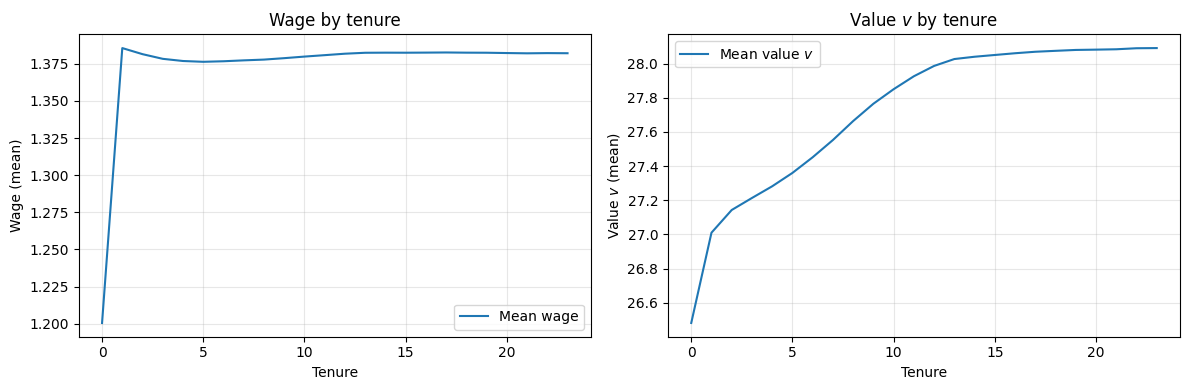

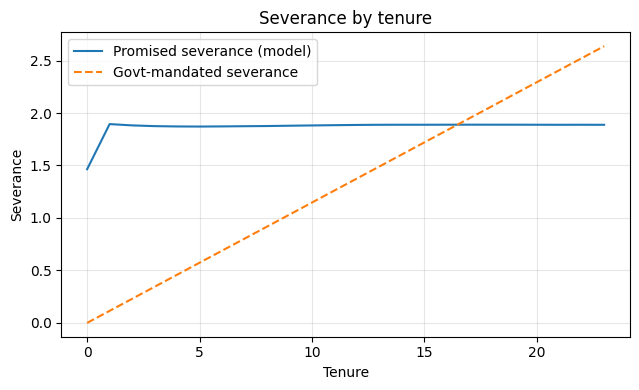

In [8]:
sim.plot(moms_mean,save_prefix = True)

coef
Intercept                0.049923
dypw                     0.030729
C(tenure)[T.1.0]        -0.038523
C(tenure)[T.2.0]        -0.042428
C(tenure)[T.3.0]        -0.043515
C(tenure)[T.4.0]        -0.044763
C(tenure)[T.5.0]        -0.045751
C(tenure)[T.6.0]        -0.046417
C(tenure)[T.7.0]        -0.046841
C(tenure)[T.8.0]        -0.047480
C(tenure)[T.9.0]        -0.047667
C(tenure)[T.1.0]:dypw   -0.003091
C(tenure)[T.2.0]:dypw   -0.003374
C(tenure)[T.3.0]:dypw    0.000505
C(tenure)[T.4.0]:dypw    0.002080
C(tenure)[T.5.0]:dypw    0.000273
C(tenure)[T.6.0]:dypw    0.000592
C(tenure)[T.7.0]:dypw   -0.000390
C(tenure)[T.8.0]:dypw   -0.000347
C(tenure)[T.9.0]:dypw    0.000347
Name: regressions_mean, dtype: float64

In [6]:
moms_unt_mean['sep_ten']

coef
Intercept           0.044047
C(tenure)[T.1.0]   -0.031365
C(tenure)[T.2.0]   -0.037618
C(tenure)[T.3.0]   -0.040328
C(tenure)[T.4.0]   -0.042144
C(tenure)[T.5.0]   -0.042952
C(tenure)[T.6.0]   -0.043145
C(tenure)[T.7.0]   -0.043545
C(tenure)[T.8.0]   -0.043473
C(tenure)[T.9.0]   -0.043594
Name: regressions_mean, dtype: float64

# Policies

## Min wage: 2 cases, no min wage (aka equal to the unemployment value), and 20% hike

## Severance pay: first I show the shape of the severance pay, then a consider a raise in it?? How tho?